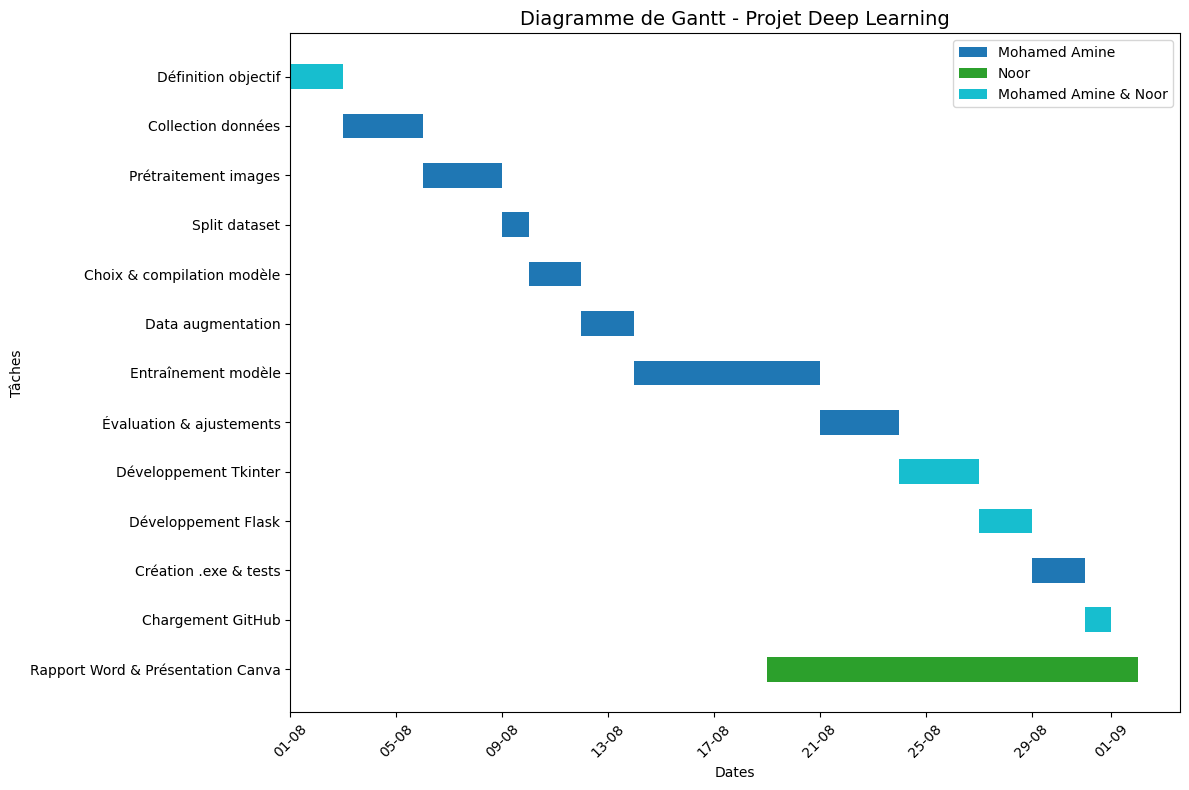

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# =========================
# Définition des tâches
# =========================
tasks = [
    {"name": "Définition objectif", "start": "2025-08-01", "end": "2025-08-02", "responsible": "Mohamed Amine & Noor"},
    {"name": "Collection données", "start": "2025-08-03", "end": "2025-08-05", "responsible": "Mohamed Amine"},
    {"name": "Prétraitement images", "start": "2025-08-06", "end": "2025-08-08", "responsible": "Mohamed Amine"},
    {"name": "Split dataset", "start": "2025-08-09", "end": "2025-08-09", "responsible": "Mohamed Amine"},
    {"name": "Choix & compilation modèle", "start": "2025-08-10", "end": "2025-08-11", "responsible": "Mohamed Amine"},
    {"name": "Data augmentation", "start": "2025-08-12", "end": "2025-08-13", "responsible": "Mohamed Amine"},
    {"name": "Entraînement modèle", "start": "2025-08-14", "end": "2025-08-20", "responsible": "Mohamed Amine"},
    {"name": "Évaluation & ajustements", "start": "2025-08-21", "end": "2025-08-23", "responsible": "Mohamed Amine"},
    {"name": "Développement Tkinter", "start": "2025-08-24", "end": "2025-08-26", "responsible": "Mohamed Amine & Noor"},
    {"name": "Développement Flask", "start": "2025-08-27", "end": "2025-08-28", "responsible": "Mohamed Amine & Noor"},
    {"name": "Création .exe & tests", "start": "2025-08-29", "end": "2025-08-30", "responsible": "Mohamed Amine"},
    {"name": "Chargement GitHub", "start": "2025-08-31", "end": "2025-08-31", "responsible": "Mohamed Amine & Noor"},
    {"name": "Rapport Word & Présentation Canva", "start": "2025-08-19", "end": "2025-09-01", "responsible": "Noor"}
]

# =========================
# Couleurs selon responsable
# =========================
colors = {
    "Mohamed Amine": "#1f77b4",        # bleu
    "Noor": "#2ca02c",                 # vert
    "Mohamed Amine & Noor": "#17becf"  # turquoise
}

# =========================
# Préparation des données pour matplotlib
# =========================
task_names = [task["name"] for task in tasks]
start_dates = [datetime.strptime(task["start"], "%Y-%m-%d") for task in tasks]
end_dates = [datetime.strptime(task["end"], "%Y-%m-%d") for task in tasks]
durations = [(end - start).days + 1 for start, end in zip(start_dates, end_dates)]
task_colors = [colors[task["responsible"]] for task in tasks]

# =========================
# Création du diagramme de Gantt
# =========================
fig, ax = plt.subplots(figsize=(12, 8))

for i, (start, duration, color) in enumerate(zip(start_dates, durations, task_colors)):
    ax.barh(i, duration, left=start, height=0.5, color=color)

# Labels et axes
ax.set_yticks(range(len(task_names)))
ax.set_yticklabels(task_names)
ax.invert_yaxis()  # La première tâche en haut
ax.xaxis_date()

# Formatage des dates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
plt.xticks(rotation=45)
plt.title("Diagramme de Gantt - Projet Deep Learning", fontsize=14)
plt.xlabel("Dates")
plt.ylabel("Tâches")

# Légende
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=name) for name, color in colors.items()]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()


In [2]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model("modelResnet50_fixed.h5")
img_path = "image.jpg"
img = image.load_img(img_path, target_size=(128,128))
x = image.img_to_array(img)/255.0  # correspond au prétraitement à l'entraînement
x = np.expand_dims(x, axis=0)
preds = model.predict(x)
print(preds)
print(np.argmax(preds), np.max(preds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[0.05836066 0.11136032 0.09699586 0.07636478 0.18078506 0.19223687
  0.04608298 0.03653371 0.10148435 0.09979539]]
5 0.19223687
